# Step 6 - Analysis (Single + Compare)


**How this notebook is organized**

1. Select a cell/tune and resolve run(s).
2. Output plots (single or compare).
3. Input plots (single or compare).
4. Synapse plots (planned).
5. Extra analysis (tables + special cases).

Analysis logic lives in `modules_local/analysis.py`, and plotting in `modules_local/plotting.py`.


## 1. Select runs


In [1]:
# --------------------------
# Defaults (manual mode)
# --------------------------
cell_name = "PV"      # SST, SST_0, PV, PN

tunes_dir = "tunes"
model_dir = "seg_tuned"

run_single_stem = "latest"
run_compare_a = "latest"
run_compare_b = "previous"  # use "none" to disable comparison
compare_a_path = ""
compare_b_path = ""

In [2]:
# --------------------------
# Defaults (from config)
# --------------------------
from pathlib import Path
import json
from modules_local import analysis

_defaults_path = analysis.find_scp_root(Path.cwd()).resolve() / "modules_local" / "analysis_defaults.json"
_defaults = json.loads(_defaults_path.read_text())

for _k in ("plot_window", "input_plot_window"):
    if isinstance(_defaults.get(_k), list) and len(_defaults[_k]) == 2:
        _defaults[_k] = (_defaults[_k][0], _defaults[_k][1])

globals().update(_defaults)


/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


In [3]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

from modules_local import run_sim, plotting, analysis, analysis_ui

BASE_DIR = analysis.find_scp_root(Path.cwd()).resolve()
CELLS_DIR = BASE_DIR / "cells"

# Widgets (optional)
use_widgets = True
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception:
    _HAVE_WIDGETS = False


--No graphics will be displayed.


In [4]:
# Selection UI
analysis_ui.build_selection_ui(globals())

# (optional) quick selection check
analysis_ui.get_selection_from_globals(globals())


{'cell': 'PV',
 'tunes': 'tunes',
 'model': 'seg_tuned',
 'base': PosixPath('/home/hrbncv/SCP/cells/PV/tunes/seg_tuned/output_data'),
 'run_single': 'latest',
 'run_a': 'latest',
 'run_b': 'previous',
 'run_a_path': '',
 'run_b_path': '',
 'compare_list': [],
 'compare_list_paths': []}

## 2. Output plots (standard)


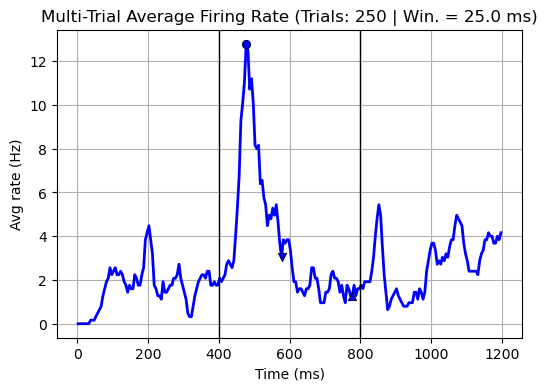

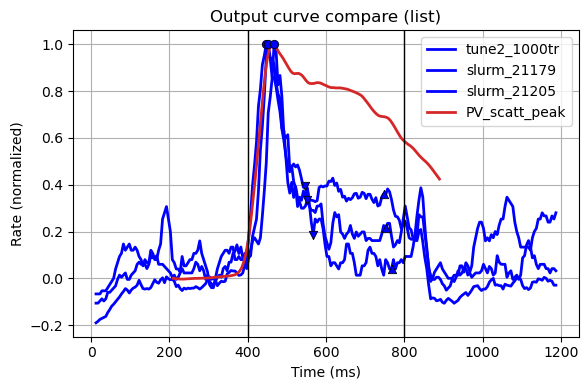

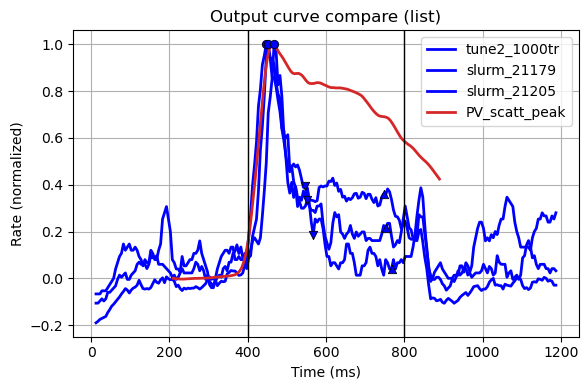

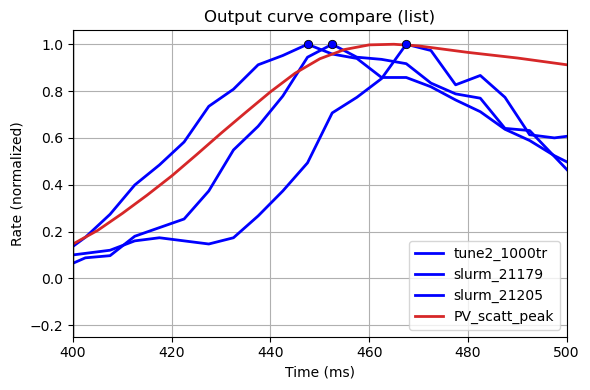

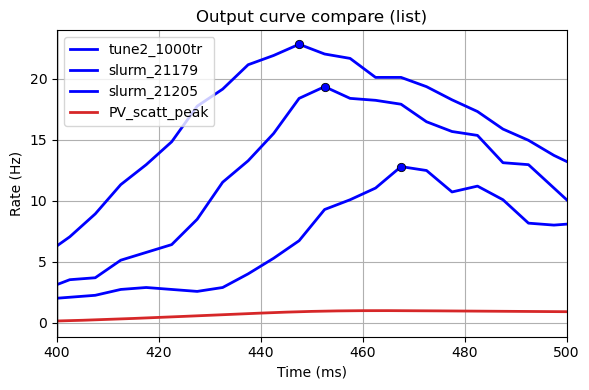

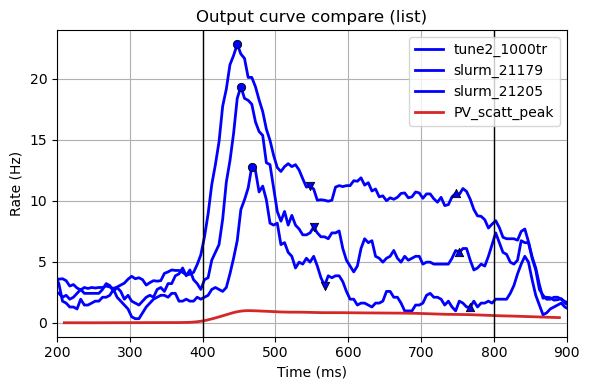

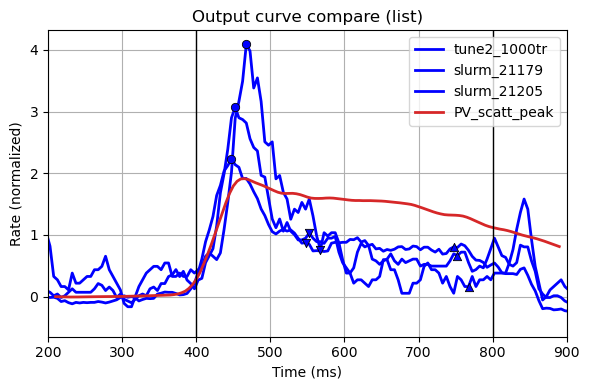

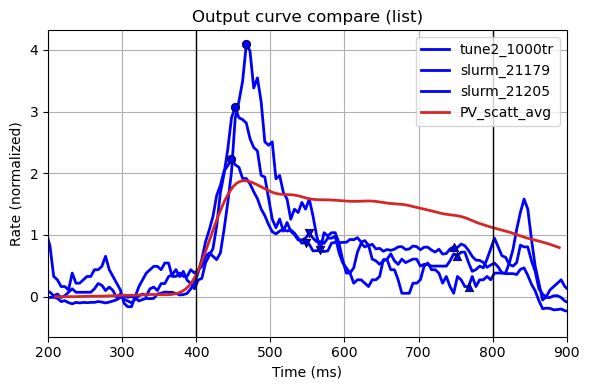

In [5]:
# Outputs UI (single or compare)
analysis_ui.build_outputs_ui(globals())


## 3. Input plots (standard)


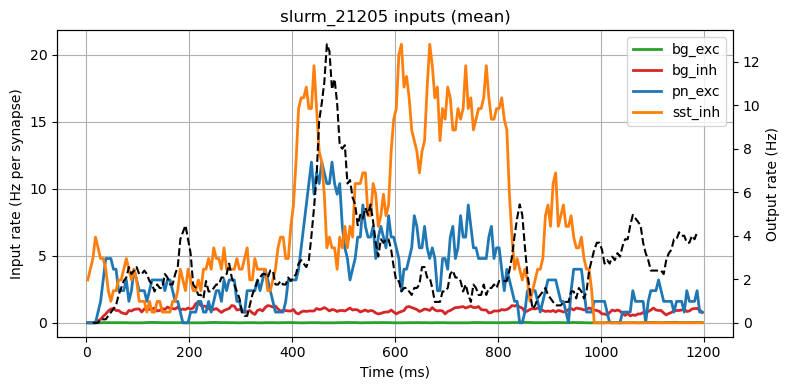

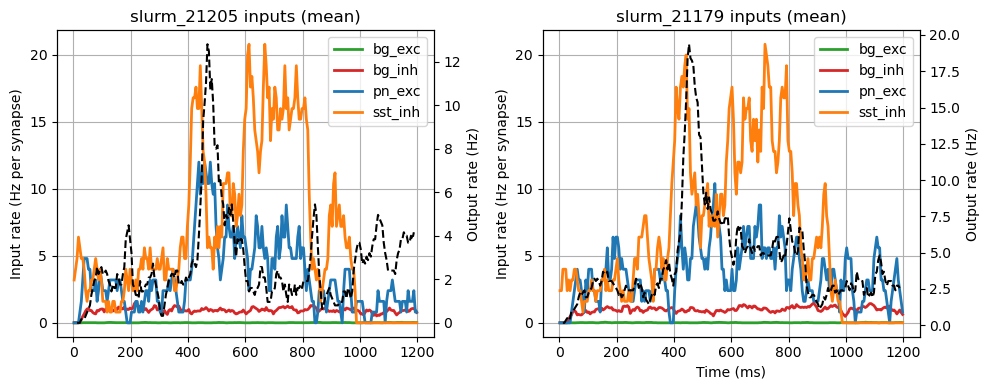

In [6]:
# Inputs UI (single or compare)
analysis_ui.build_inputs_ui(globals())


## 4. Synapse plots (planned)


## 5. Extra analysis (tables + special cases)


In [7]:
# # Manual: single-run tables (extra)
# analysis_ui.run_extra_tables_from_globals(globals())


### Output metrics (bio)


In [13]:
metrics = analysis_ui.run_output_metrics_from_globals(globals())
if metrics:
    if isinstance(metrics, dict) and all(isinstance(v, dict) for v in metrics.values()):
        analysis_ui.show_md(analysis_ui.format_kv_table_columns(metrics, title="Output metrics"))
    else:
        sel = analysis_ui.get_selection_from_globals(globals())
        label = analysis.run_label(analysis.resolve_run(sel["base"], sel["run_single"]))
        analysis_ui.show_md(analysis_ui.format_kv_table(metrics, title=f"Output metrics ({label})"))


### Output metrics
| Metric | tune2_1000tr | slurm_21179 | slurm_21205 | PV_scatt_peak |
| --- | --- | --- | --- | --- |
| peak_window_ms | 100.0 | 100.0 | 100.0 | 100.0 |
| drop_window_ms | 100.0 | 100.0 | 100.0 | 100.0 |
| auc_window | stim | stim | stim | stim |
| stim_start_ms | 400.0 | 400.0 | 400.0 | 0.0 |
| stim_stop_ms | 800.0 | 800.0 | 800.0 | None |
| peak_time_ms | 447.5 | 452.5 | 467.5 | None |
| peak_value | 1.0 | 1.0 | 1.0 | None |
| peak_rate_hz | 1.0 | 1.0 | 1.0 | None |
| peak_latency_ms | 47.5 | 52.5 | 67.5 | None |
| drop_time_ms | 547.5 | 552.5 | 567.5 | None |
| drop_value | 0.39248434237995816 | 0.3364055299539171 | 0.18666666666666668 | None |
| drop_pct | 60.75156576200418 | 66.3594470046083 | 81.33333333333333 | None |
| rebound_window_ms | 300.0 | 300.0 | 300.0 | 300.0 |
| rebound_time_ms | 747.5 | 752.5 | 767.5 | None |
| rebound_value | 0.361169102296451 | 0.2165898617511521 | 0.040000000000000015 | None |
| rebound_pct | 63.88308977035491 | 78.34101382488478 | 96.0 | None |
| auc | 178.24634655532358 | 129.51612903225808 | 97.36666666666666 | None |
| auc_units | normalized*ms | normalized*ms | normalized*ms | normalized*ms |

### 5.1 Comparison tables + synapse compare plots (optional)


In [9]:
# # Manual: comparison tables + synapse compare plots (extra)
# analysis_ui.run_extra_compare_from_globals(globals())


### 4.2 Snapshot compare tables (optional)


In [10]:
# # Manual: snapshot compare tables (extra)
# analysis_ui.run_snapshot_compare_from_globals(globals())


### 4.3 IClamp analysis (optional)


In [11]:
# # Manual: IClamp analysis (extra)
# analysis_ui.run_iclamp_analysis_from_globals(globals())


In [12]:
metrics = analysis_ui.run_output_metrics_from_globals(globals())
if metrics:
    if isinstance(metrics, dict) and all(isinstance(v, dict) for v in metrics.values()):
        analysis_ui.show_md(analysis_ui.format_kv_table_columns(metrics, title="Output metrics"))
    else:
        sel = analysis_ui.get_selection_from_globals(globals())
        label = analysis.run_label(analysis.resolve_run(sel["base"], sel["run_single"]))
        analysis_ui.show_md(analysis_ui.format_kv_table(metrics, title=f"Output metrics ({label})"))


### Output metrics (slurm_21205)
| Metric | Value |
| --- | --- |
| peak_window_ms | 100.0 |
| drop_window_ms | 100.0 |
| auc_window | stim |
| stim_start_ms | 400.0 |
| stim_stop_ms | 800.0 |
| peak_time_ms | 477.5 |
| peak_value | 12.8 |
| peak_rate_hz | 12.8 |
| peak_latency_ms | 77.5 |
| drop_time_ms | 577.5 |
| drop_value | 3.0400000000000005 |
| drop_pct | 76.25 |
| rebound_window_ms | 300.0 |
| rebound_time_ms | 777.5 |
| rebound_value | 1.2800000000000002 |
| rebound_pct | 90.0 |
| auc | 1487.6000000000004 |
| auc_units | Hz*ms |